In [1]:
import os

os.environ["JAX_ENABLE_X64"] = "1"
os.environ['XLA_PYTHON_CLIENT_MEM_FRACTION'] = '0.1' 

%matplotlib widget

import jax
import matplotlib.pyplot as plt
import numpy as np

from temgym_core.gaussian import (
    InterpolatedSample2D,
    sample_input_wave,
) 
from temgym_core.evaluate import evaluate_gaussians_gpu_kernel_wrapper
from temgym_core.transfer_matrices import calculate_z1_and_z2_from_M_and_f
from temgym_core.constants import energy2wavelength
from temgym_core.aberrations import KrivanekCoeffs
from temgym_core.plotting import plot_model, PlotParams
from temgym_core.utils import make_tilted_uniform_cube, project_phase_along_z

from libertem_holo.base.reconstr import reconstruct_frame, phase_unwrap
from libertem_holo.base.utils import HoloParams
from libertem_holo.base.align import get_slice_fft
from libertem_holo.base.utils import remove_phase_ramp

from temgym_core.components import Detector

import jax.numpy as jnp

jax.config.update("jax_enable_x64", True)

In [2]:
voltage_eV = 200e3
input_window_width_m = 4000e-9
fringe_spacing = 3e-9
num_pixels = 128
beam_waist = 20e-9
overlap_factor = 1.0
input_cube_xy = (0.6e-6, 0.0e-6)
input_cube_side_length = 400e-9
input_cube_x_tilt = np.deg2rad(22)  # degrees

# Create input field
wavelength = energy2wavelength(voltage_eV)
k = 2 * np.pi / wavelength
pixel_size = input_window_width_m / num_pixels

simulation_side_length = input_cube_side_length * 2
cube_fraction = input_cube_side_length / simulation_side_length
sample_fields, sample_x_coords, sample_y_coords, sample_z_coords = make_tilted_uniform_cube(
    tilt_x=input_cube_x_tilt,
    L=simulation_side_length,
    cube_fraction=cube_fraction,
    x0=input_cube_xy[0],
    y0=input_cube_xy[1],
    B0=0.05,
    V0=0.01,
    amplitude_dampening=0.5,
)
sample_amp, sample_phase_shift = project_phase_along_z(
    fields=sample_fields,
    z_coords=sample_z_coords,
    voltage=voltage_eV,
)
sample_field = sample_amp * np.exp(1j * sample_phase_shift / k)

sample_interpolator = InterpolatedSample2D.from_array(sample=sample_field, x_coords=sample_x_coords, y_coords=sample_y_coords, z=0.0, method='cubic').interpolator

rays_in = sample_input_wave(voltage=voltage_eV,
                            aperture_length=input_window_width_m * 1.0,
                            waist=beam_waist,
                            overlap_factor=overlap_factor,
                            z0=0.0,
                            sample_interpolator=sample_interpolator)

input_grid = Detector(
z=0.0,
pixel_size=(pixel_size, pixel_size),
shape=(num_pixels, num_pixels),
)

input_field = evaluate_gaussians_gpu_kernel_wrapper(rays_in, input_grid).block_until_ready()

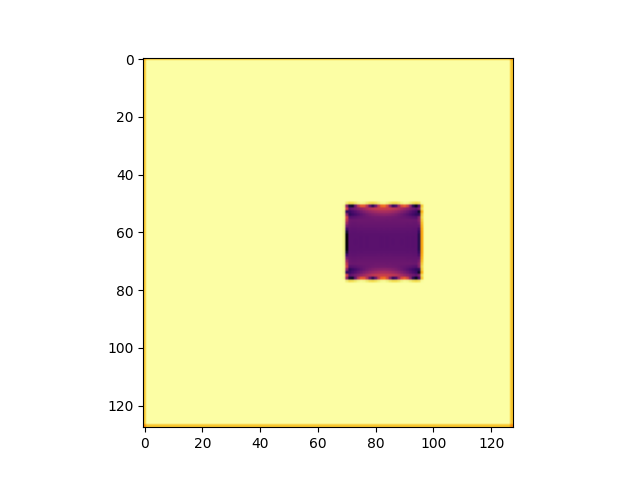

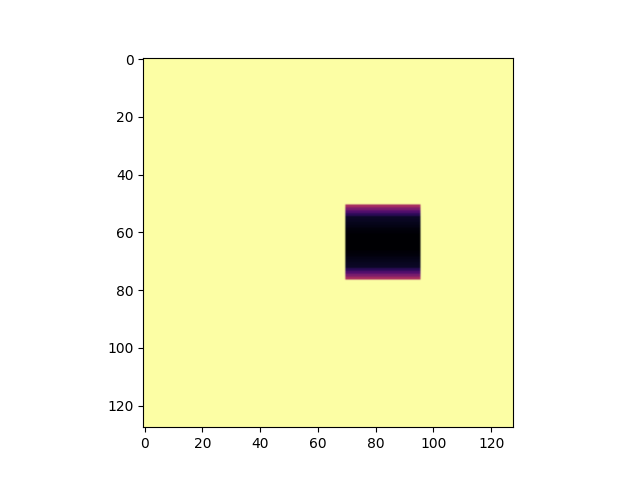

In [3]:
xy = input_grid.coords
x, y = xy[:, 0], xy[:, 1]
sample_field = sample_interpolator(x, y).reshape(input_grid.shape)
plt.figure()
plt.imshow(np.abs(input_field), cmap='inferno')

plt.figure()
plt.imshow(np.abs(sample_field), cmap='inferno')


3.878288117149014e-07


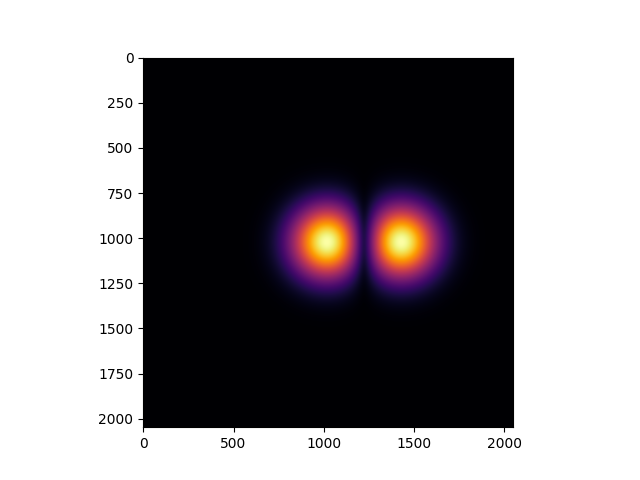

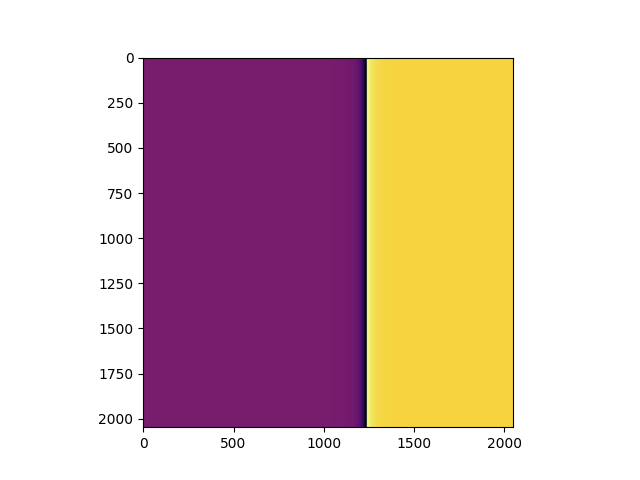

In [4]:
from temgym_core.gaussian import make_gaussian, run_to_end
from temgym_core.evaluate import evaluate_gaussians_for


def _field_on_grid(ray, grid: Detector) -> np.ndarray:
    field = evaluate_gaussians_for(ray, grid)
    return np.asarray(field)

pixel_size = (1e-8, 1e-8)
shape = (2048, 2048)

detector = Detector(z=0.0, pixel_size=pixel_size, shape=shape)
input_grid = Detector(z=0.0, pixel_size=pixel_size, shape=shape)

wo = 2e-6
voltage = 1e-5
wavelength = energy2wavelength(voltage)
k = 2 * np.pi / wavelength
print(wavelength)
x01, y01, dx01, dy01, phase1 = 4e-6, 0.0, 0.0, 0.0, 0.213 * k
x02, y02, dx02, dy02, phase2 = 0.0, 0.0, 0.0, 0.0, 0.787 * k

def _make_single_gaussian(x0, y0, dx0, dy0, phase):
    return make_gaussian(
        x=x0,
        y=y0,
        dx=dx0,
        dy=dy0,
        z=0.0,
        voltage=voltage,
        waist_x=wo,
        waist_y=wo,
        amp=1.0,
        phase=phase,
        rcurv_x=jnp.inf,
        rcurv_y=jnp.inf,
    )

rays_in = [
    _make_single_gaussian(x01, y01, dx01, dy01, phase1),
    _make_single_gaussian(x02, y02, dx02, dy02, phase2),
]

analytic_fields = []
input_fields = []

for ray in rays_in:
    propagated = run_to_end(ray, (detector,))
    analytic_fields.append(_field_on_grid(propagated, detector))

analytic_gauss_image = np.sum(analytic_fields, axis=0)

plt.figure()
plt.imshow(np.abs(analytic_gauss_image), cmap='inferno')

plt.figure()
plt.imshow(np.round(np.angle(analytic_gauss_image), 4), cmap='inferno')

